# Weather Prediction — The 12 Step Method

**Question:** Will it rain tomorrow?  (Answer: Yes or No)

**Dataset:** `weather.csv` — keep this file in the **same folder** as this notebook.

**Model we will use:** Logistic Regression

---

### The 12 Steps

| Step | What we do |
|---|---|
| 0 | Install libraries (only once on a new computer) |
| 1 | Import libraries |
| 2 | Import data |
| 3 | Copy data into a DataFrame |
| 4 | Find nulls, outliers, skew and bias |
| 5 | Scaling the data |
| 6 | Fit and transform |
| 7 | Divide into train and test |
| 8 | Train the model (`model.fit`) |
| 9 | Make predictions (`model.predict`) |
| 10 | Check the model on test data |
| 11 | Test with our own new values |
| 12 | Export the model for the web app |

**Every project follows these same 12 steps.** Only the data and the model change.

Run each cell with **Shift + Enter**.

---
# STEP 0 — Install Libraries

Run this cell **only once** on a new computer. After that you can skip it.

If a library is already installed, Python will simply say *"Requirement already satisfied"* —
that is not an error.

In [275]:
#!pip install pandas
#!pip install numpy 

#  numpy is a fundamental package for scientific computing in Python.
#  It provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays.

#!pip install matplotlib

#  matplotlib is a plotting library for the Python programming language and its numerical mathematics extension NumPy.

#!pip install seaborn
#!pip install scikit-learn
#!pip install joblib

%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


**Notes**

- The `!` at the start tells Jupyter to run the command outside Python.
- The library is called **scikit-learn** when installing, but **sklearn** when importing.
- If you are using Anaconda, most of these are already installed.
- After installing, restart the kernel once: menu **Kernel → Restart**.

---
# STEP 1 — Import Libraries

These are the tools we need. We import them once at the top.

In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Step 1 done - all libraries imported")

Step 1 done - all libraries imported


---
# STEP 2 — Import Data

We read the CSV file directly from the disk.

The file `weather.csv` must be in the **same folder** as this notebook.

In [277]:
data = pd.read_csv("weather.csv")

print("Step 2 done - data imported")
print("Rows and Columns:", data.shape)

Step 2 done - data imported
Rows and Columns: (2000, 6)


If your file is somewhere else, write the full path instead:

```python
data = pd.read_csv("C:/AI_Training/weather.csv")        # Windows
data = pd.read_csv("/home/user/AI_Training/weather.csv")  # Mac / Linux
```

In Windows always use forward slashes `/` in the path.

---
# STEP 3 — Copy Data into a DataFrame

We make a copy and work on the copy.

The original `data` stays safe, so if we make a mistake we can start again without reading
the file.

In [278]:
df = data.copy()

df.head()
#df.tail()
#df.sample()
#df.iloc[5:10]

,temperature,humidity,wind_speed,pressure,cloud_cover,rain_tomorrow
0,31.2,87.4,28.6,1004.7,57.7,Yes
1,21.2,55.7,14.3,1015.4,30.5,No
2,33.8,96.2,34.1,1007.7,71.0,Yes
3,28.9,72.1,9.6,1000.5,88.2,Yes
4,10.8,29.3,21.5,1010.0,64.6,No


In [279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    1982 non-null   float64
 1   humidity       1975 non-null   float64
 2   wind_speed     1988 non-null   float64
 3   pressure       1991 non-null   float64
 4   cloud_cover    2000 non-null   float64
 5   rain_tomorrow  2000 non-null   str    
dtypes: float64(5), str(1)
memory usage: 93.9 KB


In [280]:
df.describe().round(2)

,temperature,humidity,wind_speed,pressure,cloud_cover
count,1982.00,1975.00,1988.00,1991.00,2000.00
mean,23.18,60.44,19.72,1012.02,50.05
std,9.17,36.05,14.22,7.06,28.86
min,8.00,20.10,0.00,990.60,0.10
25%,15.40,39.80,9.67,1007.50,24.60
50%,22.95,59.80,19.30,1011.70,51.00
75%,30.90,79.75,29.30,1016.75,74.10
max,150.00,999.00,400.00,1035.10,99.90


**Columns**

| Column | Meaning |
|---|---|
| temperature | today's temperature (°C) |
| humidity | today's humidity (%) |
| wind_speed | wind speed (km/h) |
| pressure | air pressure (hPa) |
| cloud_cover | how cloudy (%) |
| rain_tomorrow | **Yes / No — this is our answer (target)** |

---
# STEP 4 — Find Nulls, Outliers, Skew and Bias

## 4.1 Nulls (missing values)

In [281]:
df.isnull().sum()

temperature      18
humidity         25
wind_speed       12
pressure          9
cloud_cover       0
rain_tomorrow     0
dtype: int64

We fill the missing values with the **median** of that column.

We use median (the middle value) because it is not affected by very large wrong values.

In [282]:
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["humidity"] = df["humidity"].fillna(df["humidity"].median())
df["wind_speed"] = df["wind_speed"].fillna(df["wind_speed"].median())
df["pressure"] = df["pressure"].fillna(df["pressure"].median())
df["cloud_cover"] = df["cloud_cover"].fillna(df["cloud_cover"].median())
#df= df.dropna()
#df=df.fillna(df.median(axis=0))
print("Nulls now:", df.isnull().sum())

print("\n Nulls now:", df.isnull().sum().sum())

Nulls now: temperature      0
humidity         0
wind_speed       0
pressure         0
cloud_cover      0
rain_tomorrow    0
dtype: int64

 Nulls now: 0


## 4.2 Outliers

An outlier is a value that is far away from all the others — for example a humidity of 999%
or an age of 200 years.

A **boxplot** shows them. Every dot outside the box is an outlier.

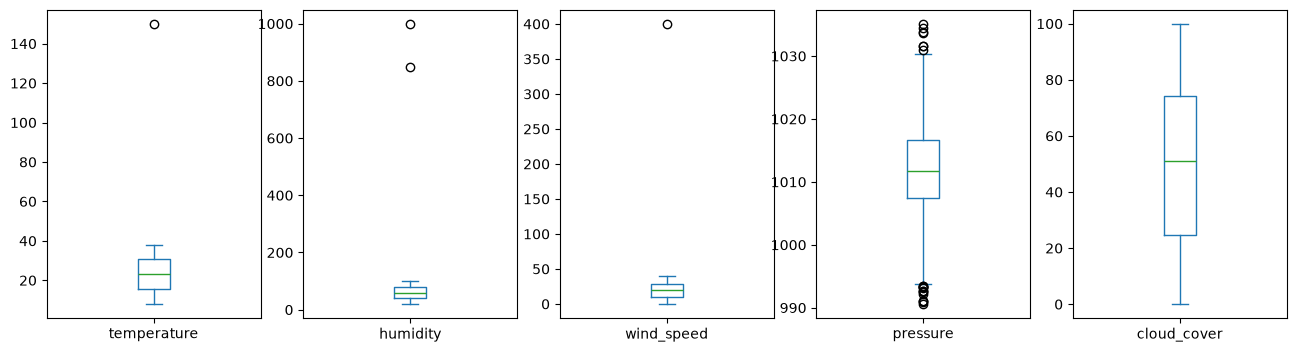

In [283]:
# import matplotlib.pyplot as plt
df.plot(kind="box", subplots=True, layout=(1, 5), figsize=(16, 4)) 
# kind="box" creates box plots for each column in the DataFrame. 
#The subplots=True argument indicates that each column should be plotted in a separate subplot. 
#The layout=(1, 5) argument specifies that the subplots should be arranged in a single row with five columns. 
# #The figsize=(16, 4) argument sets the size of the entire figure to be 16 inches wide and 4 inches tall.
plt.show()

Now we remove the impossible values.

We know the correct range for each column, so we simply keep only the sensible rows.

In [284]:
print("Rows before:", df.shape[0])

df = df[df["temperature"] <= 50] # Filter out rows where temperature is greater than 50
df = df[df["humidity"] <= 100] # Filter out rows where humidity is greater than 100
df = df[df["wind_speed"] <= 100] # Filter out rows where wind speed is greater than 100

print("Rows after :", df.shape[0]) # Print the number of rows after filtering

Rows before: 2000
Rows after : 1996


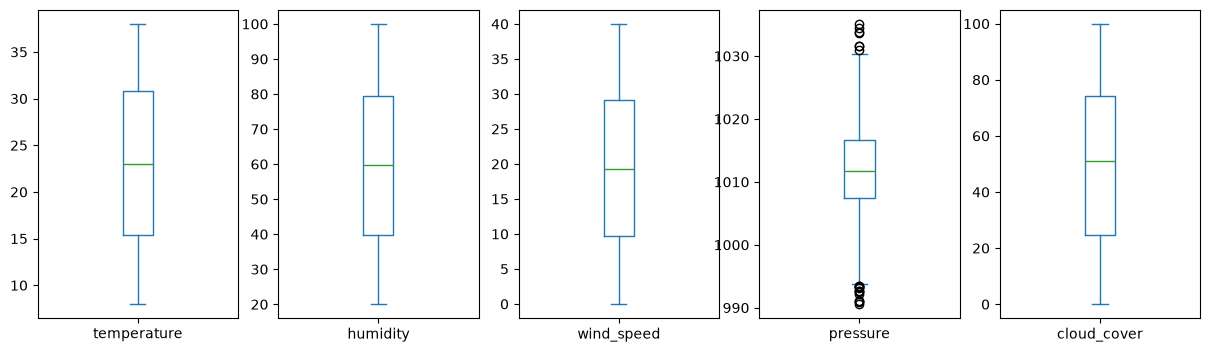

In [285]:
#import matplotlib.pyplot as plt
df.plot(kind="box", subplots=True, layout=(1, 5), figsize=(15, 4)) # kind="box" creates box plots for each column in the DataFrame.
#subplots=True argument indicates that each column should be plotted in a separate subplot.
#The layout=(1, 5) argument specifies that the subplots should be arranged in a single row with five columns.
#The figsize=(15, 4) argument sets the size of the entire figure to be 15 inches wide and 4 inches tall.    
plt.show()

## 4.3 Skew

Skew tells us if the data is balanced or leaning to one side.

| Skew value | Meaning |
|---|---|
| between -0.5 and +0.5 | good, balanced |
| between ±0.5 and ±1 | slightly leaning |
| more than +1 or less than -1 | strongly leaning, should be fixed |

In [286]:
df.skew(numeric_only=True).round(2) # skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean.

temperature    0.00
humidity       0.03
wind_speed     0.04
pressure       0.01
cloud_cover   -0.02
dtype: float64

<Axes: ylabel='Density'>

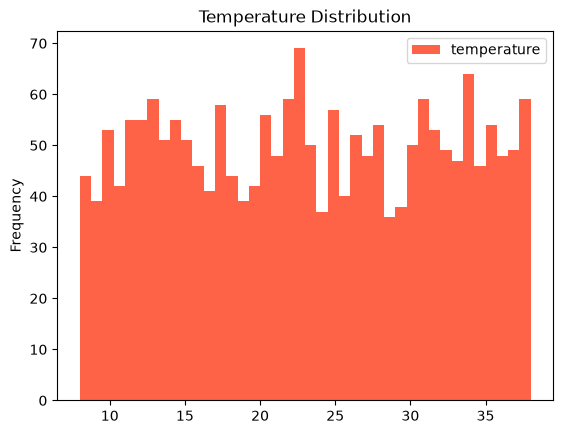

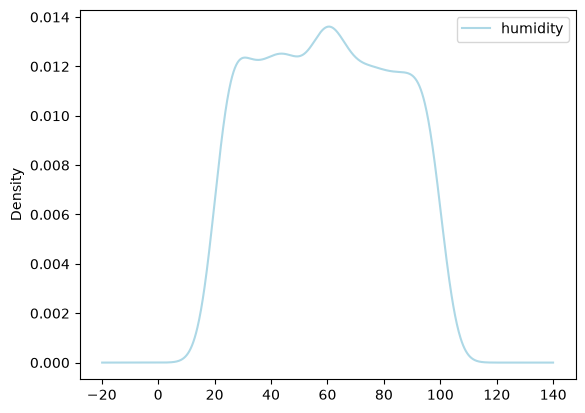

In [287]:

df.plot(kind="hist", y="temperature", color="tomato", title="Temperature Distribution", bins=40)
df.plot(kind="density", y="humidity", color="lightblue")


In [288]:
df.head(1)

,temperature,humidity,wind_speed,pressure,cloud_cover,rain_tomorrow
0,31.2,87.4,28.6,1004.7,57.7,Yes


### How do we FIX skewed data?

If a column is strongly skewed, we squeeze the long tail using a maths function.
The three common fixes are:

| Fix | Code | Use when |
|---|---|---|
| Log transform | `np.log(df["col"] + 1)` | strong positive skew (money, income, sales) |
| Square root | `np.sqrt(df["col"])` | mild positive skew (counts) |
| Square | `df["col"] ** 2` | negative skew |

We add `+ 1` inside the log because `log(0)` does not exist.

**Log is the most used one.** It pulls very large values closer to the rest, without
changing their order.

In our data every column is inside the red lines after removing the outliers,
so **no fix is needed here**. Keep the code above for projects where a column is skewed.

## 4.4 Bias in the data

A dataset is **biased** (also called *imbalanced*) when one answer appears far more often
than the other.

This is dangerous. If 95% of rows say No, a lazy model can answer No every single time and
still be 95% "accurate" — while being completely useless.

Let us check our answer column.

In [289]:
print(df["rain_tomorrow"].value_counts())
print()
print((df["rain_tomorrow"].value_counts(normalize=True) * 100).round(1))

rain_tomorrow
Yes    1027
No      969
Name: count, dtype: int64

rain_tomorrow
Yes    51.5
No     48.5
Name: proportion, dtype: float64


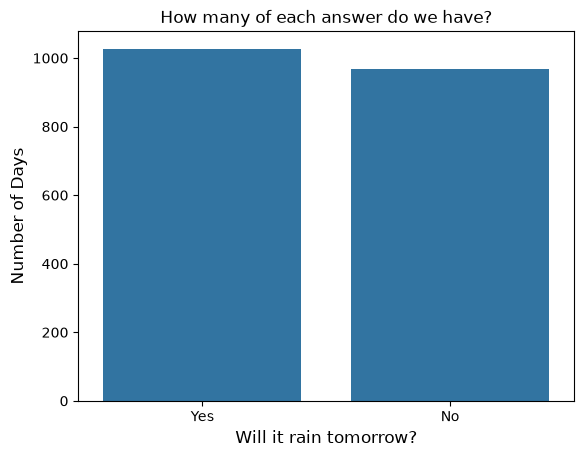

In [290]:
#import seaborn as sns
sns.countplot(x="rain_tomorrow", data=df)
plt.xlabel("Will it rain tomorrow?", fontsize=12)
plt.ylabel("Number of Days", fontsize=12)
plt.title("How many of each answer do we have?")
plt.show()

### How do we FIX biased data?

| Fix | How | Note |
|---|---|---|
| Collect more data | get more rows of the rare answer | always the best fix |
| `class_weight="balanced"` | one word inside the model | easiest, we use this |
| Undersampling | delete rows of the common answer | throws away data |
| Look at **recall**, not accuracy | change how you judge the model | always do this |

**Our data is reasonably balanced**, so no fix is needed here.

Always run this check anyway — it takes 5 seconds and it saves you from a useless model.

---
# STEP 5 — Scaling the Data

## 5.1 Separate X and y

- **X** = the input columns
- **y** = the answer column

In [291]:
X = df.drop("rain_tomorrow", axis=1)
y = df["rain_tomorrow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (1996, 5)
y shape: (1996,)


,temperature,humidity,wind_speed,pressure,cloud_cover
0,31.2,87.4,28.6,1004.7,57.7
1,21.2,55.7,14.3,1015.4,30.5
2,33.8,96.2,34.1,1007.7,71.0
3,28.9,72.1,9.6,1000.5,88.2
4,10.8,29.3,21.5,1010.0,64.6


## 5.2 Why do we need scaling?

Look at the numbers below. Some columns have very big values and some have very small ones.

The model can think the bigger number is more important, which is wrong.
Scaling brings every column to the same range.

In [292]:
X.describe().round(2)

,temperature,humidity,wind_speed,pressure,cloud_cover
count,1996.00,1996.00,1996.00,1996.00,1996.00
mean,23.12,59.58,19.54,1012.01,50.07
std,8.68,23.03,11.35,7.04,28.87
min,8.00,20.10,0.00,990.60,0.10
25%,15.40,39.90,9.70,1007.50,24.60
50%,22.95,59.80,19.30,1011.70,51.05
75%,30.80,79.32,29.20,1016.70,74.10
max,38.00,100.00,40.00,1035.10,99.90


## 5.3 Create the scaler

`StandardScaler` changes every column so that its mean becomes 0.
$$\text{Scaled Value} = \frac{x - \text{mean}}{\text{standard deviation}}$$

$$\sigma = \sqrt{\frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}}$$
$$\bar{x} = \frac{\sum_{i=1}^{N} x_i}{N}$$
$$\mu = \bar{x}

In [293]:
scaler = StandardScaler()

print("Step 5 done - scaler is ready")

Step 5 done - scaler is ready


---
# STEP 6 — Fit and Transform

- **fit** = the scaler looks at the data and learns the mean and the spread
- **transform** = the scaler changes the numbers

`fit_transform` does both together in one line.

--- STEP-BY-STEP EXAMPLE ---
Input Dataset: [10, 20, 30]
data = [10, 20, 30]
1. FIT CALCULATIONS:
Mean (μ)               = 20.00
Standard Deviation (σ) = 8.16

2. TRANSFORM ARITHMETIC:
Formula: (x - μ) / σ

For 10: (10 - 20) / 8.16 = -1.22
For 20: (20 - 20) / 8.16 =  0.00
For 30: (30 - 20) / 8.16 = +1.22
Result: [10, 20, 30] -> [-1.22, 0.00, +1.22]


python codes:
mean_val = np.mean(data)
std_val= np.sd(data)

In [294]:
#example
data=[10,20,30]
mean_val = np.mean(data)
std_val= np.std(data)

mean_val, round(std_val,2)

(np.float64(20.0), np.float64(8.16))

In [295]:
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,temperature,humidity,wind_speed,pressure,cloud_cover
0,0.931084,1.208213,0.798547,-1.039319,0.264550
1,-0.221321,-0.168309,-0.462136,0.481666,-0.677948
2,1.230709,1.590339,1.283424,-0.612875,0.725403
3,0.666031,0.543835,-0.876486,-1.636341,1.321395
4,-1.419822,-1.314687,0.172613,-0.285934,0.503639


<Axes: >

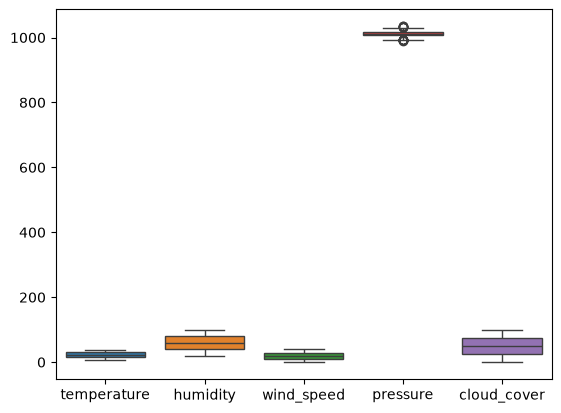

In [296]:
sns.boxplot(data=X)


<Axes: >

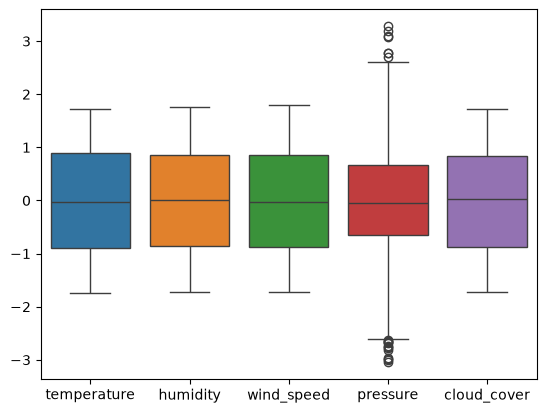

In [297]:
sns.boxplot(data=X_scaled)

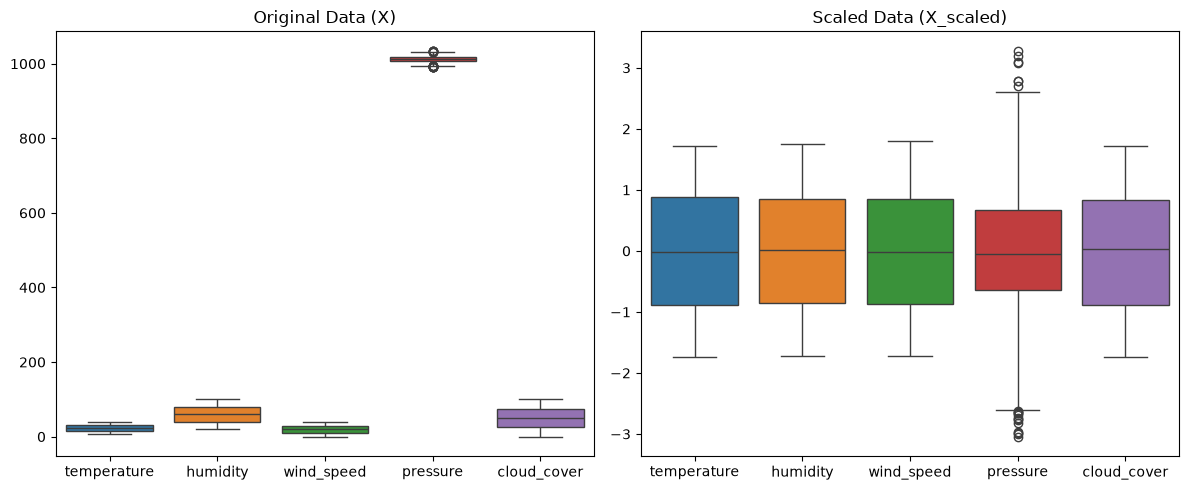

In [298]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot unscaled data on the left (index 0)
sns.boxplot(data=X, ax=axes[0])
axes[0].set_title("Original Data (X)")

# Plot scaled data on the right (index 1)
sns.boxplot(data=X_scaled, ax=axes[1])
axes[1].set_title("Scaled Data (X_scaled)")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [299]:
X.describe().round(2)

,temperature,humidity,wind_speed,pressure,cloud_cover
count,1996.00,1996.00,1996.00,1996.00,1996.00
mean,23.12,59.58,19.54,1012.01,50.07
std,8.68,23.03,11.35,7.04,28.87
min,8.00,20.10,0.00,990.60,0.10
25%,15.40,39.90,9.70,1007.50,24.60
50%,22.95,59.80,19.30,1011.70,51.05
75%,30.80,79.32,29.20,1016.70,74.10
max,38.00,100.00,40.00,1035.10,99.90


In [300]:
X_scaled.describe().round(2)

,temperature,humidity,wind_speed,pressure,cloud_cover
count,1996.00,1996.00,1996.00,1996.00,1996.00
mean,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.71,-1.72,-3.04,-1.73
25%,-0.89,-0.85,-0.87,-0.64,-0.88
50%,-0.02,0.01,-0.02,-0.04,0.03
75%,0.88,0.86,0.85,0.67,0.83
max,1.71,1.76,1.80,3.28,1.73


Look at the `mean` row above — every column is now close to **0**.

The shape of the data did not change, only the scale.

---
# STEP 7 — Divide into Train and Test

We keep **80% for training** and **hide 20% for testing**.

The model learns from the training part only. The testing part is the exam — the model has
never seen it. This is the only honest way to check a model.

`stratify=y` keeps the same mix of answers in both parts.
`random_state=42` makes everyone in the class get the same split.

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y) 
#stratify=y is an option in scikit-learn's train_test_split function that ensures that the class distribution in the training and testing sets is similar to the original dataset.

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 1596
Testing rows : 400


---
# STEP 8 — Train the Model

This is the actual machine learning. It is **one line**: `model.fit()`

## Why Logistic Regression?

**Logistic Regression** is the simplest and most popular model for Yes/No questions.

It looks at all 5 readings together and calculates a **chance** between 0 and 1.
If the chance is above 0.5 it answers Yes, otherwise No.

It is fast, it works well, and it is easy to explain — which is why we start with it.

In [302]:
model = LogisticRegression()
#model =LogisticRegression(class_weight='balanced') #class_weight='balanced' is an option in scikit-learn's LogisticRegression that automatically adjusts the weights of classes inversely proportional to their frequencies in the input data. 
# This is useful when dealing with imbalanced datasets, where one class is significantly underrepresented compared to others.
#  By using class_weight='balanced', the model gives more importance to the minority class during training, which can help improve its performance on that class.
model.fit(X_train, y_train)

print("Step 8 done - model is trained")

Step 8 done - model is trained


---
# STEP 9 — Make Predictions

Now we give the model the **test data** (which it has never seen) and ask for its answers.

In [303]:
y_pred = model.predict(X_test)

print("First 10 predictions :", list(y_pred[:10]))
print("First 10 real answers:", list(y_test[:10]))

First 10 predictions : ['Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes']
First 10 real answers: ['Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes']


In [304]:
result = pd.DataFrame({"Real Answer": y_test.values,
                       "Model Prediction": y_pred})

result.head(5)

,Real Answer,Model Prediction
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,No,No
4,Yes,Yes


---
# STEP 10 — Check the Model

## 10.1 How many did the model get correct?

In [305]:
correct = (y_pred == y_test).sum() # Count the number of correct predictions
total = len(y_test) # Count the total number of test samples

print("Total test rows      :", total)
print("Correctly predicted  :", correct)
print("Wrongly predicted    :", total - correct)

Total test rows      : 400
Correctly predicted  : 361
Wrongly predicted    : 39


In [306]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in percent:", round(accuracy * 100, 2), "%")

Accuracy: 0.9025
Accuracy in percent: 90.25 %


## 10.2 Confusion Matrix

This table shows exactly which mistakes the model made.
The numbers on the diagonal are the correct answers.

In [307]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
#confusion_matrix is a function from scikit-learn that computes the confusion matrix to evaluate the accuracy of a classification.
#model.classes_ returns the unique class labels that the model was trained on.
print(cm)

[[173  21]
 [ 18 188]]


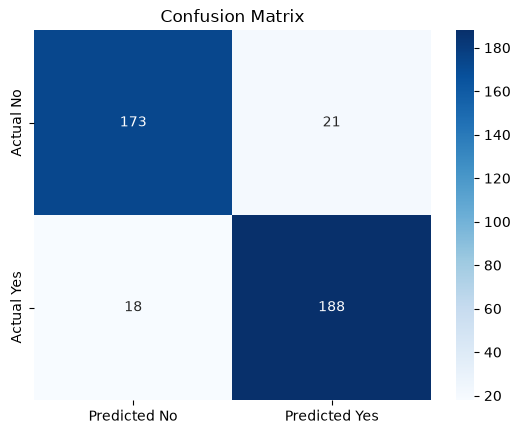

In [308]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted " + c for c in model.classes_],
            yticklabels=["Actual " + c for c in model.classes_])
plt.title("Confusion Matrix")
plt.show()

## 10.3 Full report

In [309]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.91      0.89      0.90       194
         Yes       0.90      0.91      0.91       206

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



| Word | Meaning |
|---|---|
| precision | when the model gave this answer, how often was it right |
| recall | out of all the real cases, how many did the model catch |
| f1-score | balance of precision and recall |
| support | how many rows of that type were in the test data |

## 10.4 Check the training score also

If the training score is very high but the test score is low, the model has **memorised**
the training data instead of learning. That is called **overfitting**.

In [310]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training accuracy:", round(train_accuracy * 100, 2), "%")
print("Testing accuracy :", round(test_accuracy * 100, 2), "%")
print("Difference       :", round((train_accuracy - test_accuracy) * 100, 2), "%")

Training accuracy: 89.22 %
Testing accuracy : 90.25 %
Difference       : -1.03 %


A small difference means the model is healthy.

A large difference (more than about 10%) means overfitting — use a simpler model, or a
smaller `max_depth`, or collect more data.

---
# STEP 11 — Test the Model with New Data

Now we give the model values that are **not in the file at all** — values that we type
ourselves.

**Very important:** new data must be prepared in exactly the same way as the training data.

1. Put the values in a DataFrame with the **same column names and same order**
2. Scale it with the **same scaler**
3. Only then call `predict`

Column order: `temperature, humidity, wind_speed, pressure, cloud_cover`

## 11.1 Type your own values

Change the numbers below to anything you like, then run the cell.

In [311]:
new_row = pd.DataFrame([[26, 92, 15, 1004, 88]], columns=X.columns)

new_row

,temperature,humidity,wind_speed,pressure,cloud_cover
0,26,92,15,1004,88


## 11.2 Scale the new data

We use `transform` here, **not** `fit_transform`.

The scaler already learned in Step 6. If we used `fit_transform` here, it would learn again
from one single row and the prediction would be wrong.

In [312]:
new_row_scaled = scaler.transform(new_row)

new_row_scaled = pd.DataFrame(new_row_scaled, columns=X.columns)

new_row_scaled

,temperature,humidity,wind_speed,pressure,cloud_cover
0,0.331833,1.407961,-0.400424,-1.138823,1.314464


## 11.3 Predict

In [313]:
prediction = model.predict(new_row_scaled)

print("Will it rain tomorrow?", prediction[0])

Will it rain tomorrow? Yes


## 11.4 How sure is the model?

`predict` gives only the answer. `predict_proba` gives the **chance** behind that answer.

In [314]:
probability = model.predict_proba(new_row_scaled)

chances = pd.DataFrame({"answer": model.classes_,
                        "chance_%": (probability[0] * 100).round(2)})

chances

,answer,chance_%
0,No,0.01
1,Yes,99.99


## 11.5 Try a few different cases at once

In [315]:
many_rows = pd.DataFrame([
    [26, 92, 15, 1004, 88],    # humid and cloudy day
    [34, 30,  8, 1020, 10],    # hot and dry day
    [27, 65, 12, 1012, 50],    # normal day
], columns=X.columns)

many_rows_scaled = pd.DataFrame(scaler.transform(many_rows), columns=X.columns)

results = many_rows.copy()
results["prediction"] = model.predict(many_rows_scaled)

results

,temperature,humidity,wind_speed,pressure,cloud_cover,prediction
0,26,92,15,1004,88,Yes
1,34,30,8,1020,10,No
2,27,65,12,1012,50,Yes


---
# STEP 12 — Export the Model for the Web App

Training took a few seconds here, but on real data it can take hours. We do not want to
train the model again every time someone opens the app.

So we **save the trained model into a file**. This is called **pickling**.

Think of it like cooking: training is the cooking, the `.pkl` file is the meal in the
freezer, and the app just reheats it.

## 12.1 What do we save?

We must save **three** things together, not just the model:

| What | Why |
|---|---|
| the **model** | it makes the prediction |
| the **scaler** | new data must be scaled the same way, or the answer will be wrong |
| the **column names** | so the app sends the columns in the correct order |

In [316]:
import joblib

package = {
    "model": model,
    "scaler": scaler,
    "columns": list(X.columns)
}

joblib.dump(package, "weather_model.pkl")

print("Model saved as weather_model.pkl")

Model saved as weather_model.pkl


## 12.2 Always test the saved file

Never build an app on top of a `.pkl` file you have not tested.

In [317]:
loaded = joblib.load("weather_model.pkl")

loaded_model = loaded["model"]
loaded_scaler = loaded["scaler"]
loaded_columns = loaded["columns"]

print("Columns the model expects:", loaded_columns)

Columns the model expects: ['temperature', 'humidity', 'wind_speed', 'pressure', 'cloud_cover']


In [318]:
test_row = pd.DataFrame([[26, 92, 15, 1004, 88]], columns=loaded_columns)

test_row_scaled = pd.DataFrame(loaded_scaler.transform(test_row), columns=loaded_columns)

print("Prediction from the saved file:", loaded_model.predict(test_row_scaled)[0])

Prediction from the saved file: Yes


If the answer above is the same as in Step 11.3, the file is correct and ready to use.

## 12.3 Create requirements.txt automatically

When we put the app on the internet, the server is an empty computer. It has no pandas and
no scikit-learn until we tell it what to install. That list goes in **requirements.txt**.

There is one important detail. A `.pkl` file saved by scikit-learn version 1.5 may **refuse
to open** on a server that installed version 1.8. This is the most common reason a working
app fails after hosting.

The safe way is to write down the exact versions of **this** computer, because this is the
computer that created the `.pkl` file.

In [319]:
import sklearn

lines = [
    "streamlit",
    "pandas==" + pd.__version__,
    "numpy==" + np.__version__,
    "scikit-learn==" + sklearn.__version__,
    "joblib==" + joblib.__version__,
]

text = "\n".join(lines)

file = open("requirements.txt", "w")
file.write(text)
file.close()

print("requirements.txt created with these lines:")
print()
print(text)

requirements.txt created with these lines:

streamlit
pandas==3.0.5
numpy==2.4.6
scikit-learn==1.9.0
joblib==1.5.3


## 12.4 What to upload to GitHub

| File | Needed for the app? |
|---|---|
| `weather_app.py` | YES - the app itself |
| `weather_model.pkl` | YES - the trained model |
| `requirements.txt` | YES - the list of libraries |
| `weather.csv` | No - only used for training |
| this notebook | No - but nice to keep |

Upload the **first three** to a **public** GitHub repository, then deploy from
share.streamlit.io with Main file path = `weather_app.py`.

The app does **not** read the CSV file. It only reads the `.pkl` file. That is the whole
point of exporting the model.

---
# Finished

| Step | What we did |
|---|---|
| 0 | Installed the libraries |
| 1 | Imported libraries |
| 2 | Imported the CSV file |
| 3 | Copied it into a DataFrame |
| 4 | Fixed nulls, removed outliers, checked skew and bias |
| 5 | Separated X and y, created the scaler |
| 6 | fit_transform on the data |
| 7 | Split into 80% train and 20% test |
| 8 | Trained the Logistic Regression model |
| 9 | Predicted on the test data |
| 10 | Checked how many predictions were correct |
| 11 | Tested with our own new values |
| 12 | Saved `weather_model.pkl` and created requirements.txt |

**Next:** run the web app.

```
streamlit run weather_app.py
```